# Inlämningsuppgift – Klassificera ansiktsuttryck med neurala nätverk

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(42)

## 1) Förstå datan

In [2]:
# Laddar in datan

train_folder = "data/FER-2013/train"
test_folder = "data/FER-2013/test"

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

def load_fer2013_data(folder, class_names):
    images = []
    labels = []

    for label, class_name in enumerate(class_names):
        class_folder = folder + "/" + class_name

        for image_name in os.listdir(class_folder):
            image_file = class_folder + "/" + image_name

            image = load_img(
                image_file,
                color_mode="grayscale",
                target_size=(48, 48)
            )

            image = img_to_array(image)
            image = image.squeeze()

            images.append(image)
            labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    return images, labels


train_images_full, train_labels_full = load_fer2013_data(train_folder, class_names)
test_images, test_labels = load_fer2013_data(test_folder, class_names)

In [5]:
print("Bilder i train set:", train_images_full.shape)
print("Bilder i test set:", test_images.shape)
print("Bilder totalt:", len(train_labels_full) + len(test_labels))
print("Klasser:", np.unique(test_labels))

Bilder i train set: (28709, 48, 48)
Bilder i test set: (7178, 48, 48)
Bilder totalt: 35887
Klasser: [0 1 2 3 4 5 6]


### Summering av dataset

- Datasetet innehåller 35,887 bilder där varje bild representeras i 48 x 48 pixels var.
- Datasetet är indelat i train-set - 28,709 bilder och test-set - 7,178. 
- Det finns 7 klasskategorier eller *labels* som bilderna kan hamna inom - *labels* är en vektor av integers från 0 till 6. Dessa representerar vilken sort av ansiktsuttryck bilder hamnar inom:

| Label       | Class       |
| ----------- | ----------- |
| 0 	      |  angry      |
| 1 	      |  disgust    |
| 2 	      |  fear       |
| 3 	      |  happy      |
| 4 	      |  neutral    |
| 5 	      |  sad        |
| 6 	      |  surprise   |

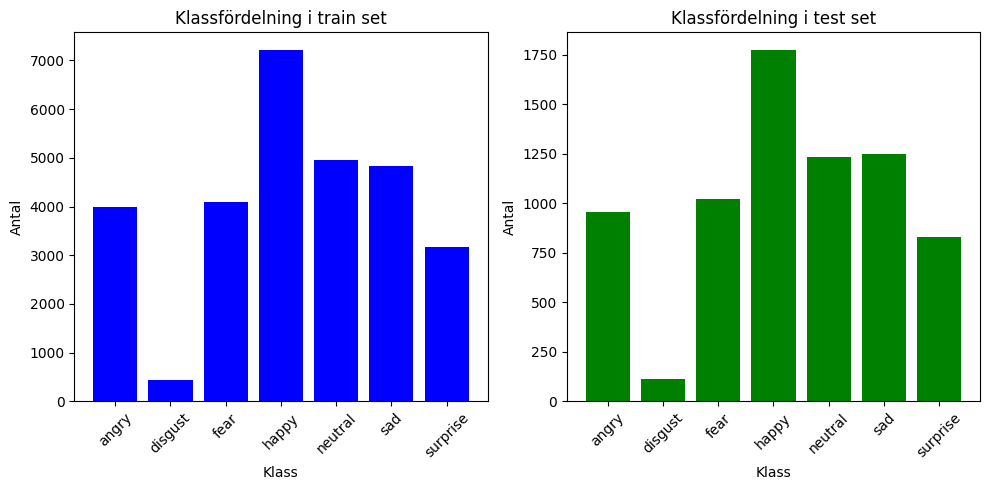

In [3]:
# Identifierar eventuella obalanser

classes_train, counts_train = np.unique(train_labels_full, return_counts=True)
classes_test, counts_test = np.unique(test_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(classes_train, counts_train, color='blue')
axes[0].set_title('Klassfördelning i train set')
axes[0].set_xlabel('Klass')
axes[0].set_ylabel('Antal')
axes[0].set_xticks(classes_train)
axes[0].set_xticklabels(class_names, rotation=45)

axes[1].bar(classes_test, counts_test, color='green')
axes[1].set_title('Klassfördelning i test set')
axes[1].set_xlabel('Klass')
axes[1].set_ylabel('Antal')
axes[1].set_xticks(classes_test)
axes[1].set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

Datasetet är obalanserat, där vissa klasser förekommer betydligt oftare än andra. För att minska träningstiden och göra klassfördelningen jämnare skapar jag därför ett balanserat subset med lika många bilder från varje klass.

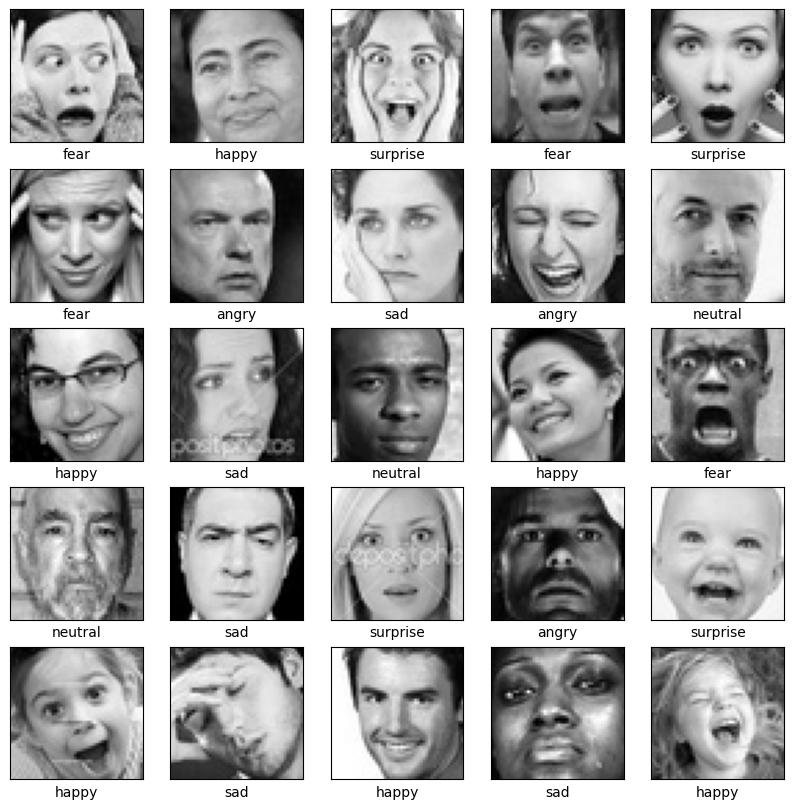

In [7]:
# Visar exempelbilder från träningsdatan

plt.figure(figsize=(10,10))

random_pictures = np.random.choice(len(train_images_full), size=25, replace=False)

for i, index in enumerate(random_pictures):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_full[index], cmap="gray")
    plt.xlabel(class_names[train_labels_full[index]])

plt.show()

## 2) Förbereda datan

In [8]:
def create_balanced_subset(X, y, samples_per_class=400, random_state=42):

    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    train_images_full,
    train_labels_full,
    samples_per_class=400,
    random_state=42
)

print("X_subset_raw:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)

X_subset_raw: (2800, 48, 48)
y_subset: (2800,)


För att minska träningstiden använder jag ett balanserat subset av träningsdatan med 400 bilder per klass. Testdatan behölls däremot i sin helhet för att modellen skulle kunna utvärderas på hela testmängden.

In [9]:
train_images, val_images, train_labels, val_labels = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

print("Train images:", train_images.shape)
print("Validation images:", val_images.shape)
print("Train labels:", train_labels.shape)
print("Validatio labels:", val_labels.shape)

Train images: (2240, 48, 48)
Validation images: (560, 48, 48)
Train labels: (2240,)
Validatio labels: (560,)


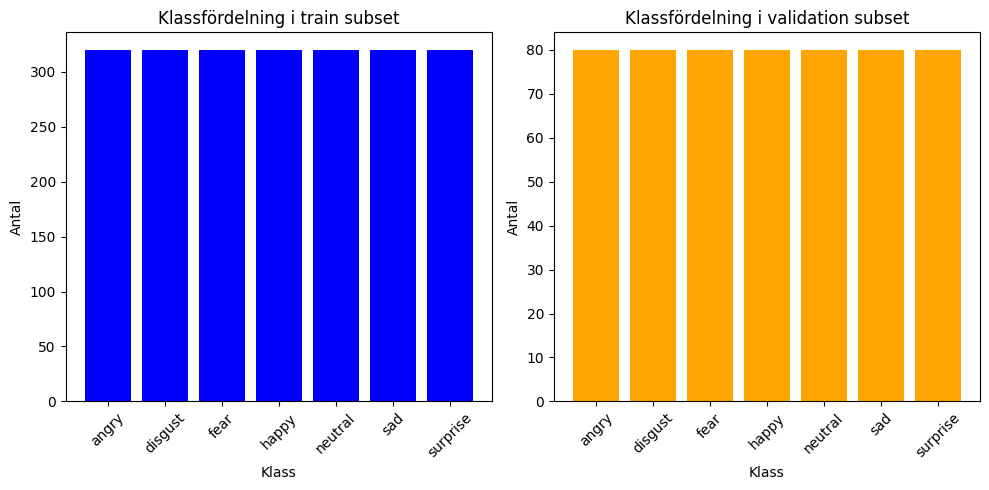

In [10]:
# Kontrolerar klassfördelning efter min split:

classes_train, counts_train = np.unique(train_labels, return_counts=True)
classes_val, counts_val = np.unique(val_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(classes_train, counts_train, color='blue')
axes[0].set_title('Klassfördelning i train subset')
axes[0].set_xlabel('Klass')
axes[0].set_ylabel('Antal')
axes[0].set_xticks(classes_train)
axes[0].set_xticklabels(class_names, rotation=45)

axes[1].bar(classes_val, counts_val, color='orange')
axes[1].set_title('Klassfördelning i validation subset')
axes[1].set_xlabel('Klass')
axes[1].set_ylabel('Antal')
axes[1].set_xticks(classes_val)
axes[1].set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Normaliserar bilderna

train_images_norm = train_images / 255.0
val_images_norm = val_images / 255.0
test_images_norm = test_images / 255.0

print("Train imgs min/max:", train_images_norm.min(), train_images_norm.max())
print("Validation imgs min/max:", val_images_norm.min(), val_images_norm.max())
print("Test imgs shape:", test_images_norm.shape)

Train imgs min/max: 0.0 1.0
Validation imgs min/max: 0.0 1.0
Test imgs shape: (7178, 48, 48)


In [12]:
# Anpassar bildformatet för CNN

train_images_norm = train_images_norm[..., np.newaxis]
val_images_norm = val_images_norm[..., np.newaxis]
test_images_norm = test_images_norm[..., np.newaxis]

print("Train imgs shape efter kanal-dimension:", train_images_norm.shape)
print("Validation imgs shape efter kanal-dimension:", val_images_norm.shape)
print("Test imgs shape efter kanal-dimension:", test_images_norm.shape)

Train imgs shape efter kanal-dimension: (2240, 48, 48, 1)
Validation imgs shape efter kanal-dimension: (560, 48, 48, 1)
Test imgs shape efter kanal-dimension: (7178, 48, 48, 1)


## 3) Bygger en modell

In [13]:
# Bygger en baseline CNN-model

def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),       # 64 neuroner 
        layers.Dense(7, activation="softmax")      # 7 klassser
    ])
    
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
    )
    
    return model

In [14]:
baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,159 (2.32 MB)

 Trainable params: 609,159 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

Skapade en baseline-modell med CNN-arkitektur. Modellen består av två convolutional layers (Conv2D) som används för att identifiera mönster i bilderna, följt av max pooling som minskar bilddimensionerna. Därefter används ett flatten-lager och dense-lager för klassificering. Det sista lagret har 7 neuroner eftersom datasetet innehåller 7 klasser. Softmax används för att modellen ska ge sannolikheter för varje klass.

In [18]:
start_time = time.time()

history_baseline = baseline_model.fit(
    train_images_norm,
    train_labels,
    validation_data = (val_images_norm, val_labels),
    epochs=5,
    batch_size=32
)

baseline_trainig_time = time.time() - start_time

print(f"Träningstid för baseline på subset: {baseline_trainig_time / 60:.2f} minuter")

Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.4723 - loss: 1.4807 - val_accuracy: 0.3411 - val_loss: 1.7713
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5080 - loss: 1.3578 - val_accuracy: 0.3643 - val_loss: 1.8057
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5527 - loss: 1.2325 - val_accuracy: 0.3661 - val_loss: 1.8446
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6210 - loss: 1.0876 - val_accuracy: 0.3625 - val_loss: 1.9336
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6808 - loss: 0.9441 - val_accuracy: 0.3536 - val_loss: 1.9520
Träningstid för baseline på subset: 0.25 minuter


## 4) Träna modellen

### Träna baseline-modellen

Efter att baseline-modellen har byggts och compile:ats tränas den på normaliserade träningsdata. 
Jag använder validation data för att kunna följa hur modellen presterar på data som den inte tränas direkt på.

I den första baseline använder jag 5 epochs och batch size 32. 
Resultatet sparas i `history_baseline`, vilket gör att man senare kan visualisera utvecklingen av loss och accuracy under träningen.

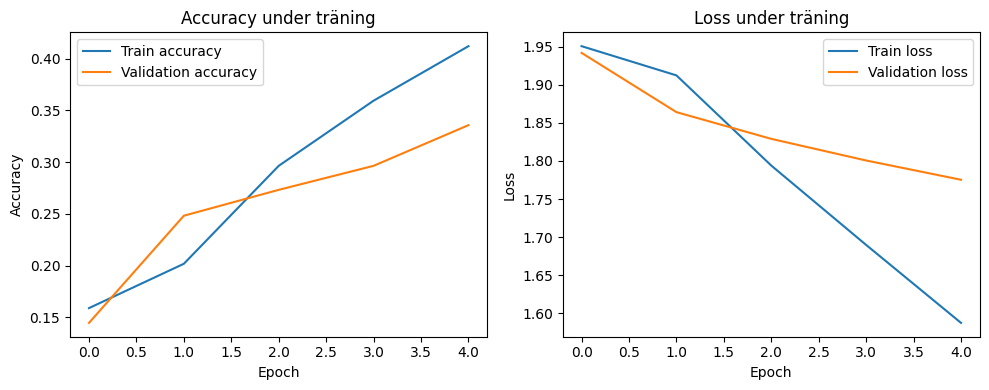

In [16]:
# Plottar accuracy/loss:

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history["accuracy"], label="Train accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation accuracy")
plt.title("Accuracy under träning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history["loss"], label="Train loss")
plt.plot(history_baseline.history["val_loss"], label="Validation loss")
plt.title("Loss under träning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 5) Utvärdera modellen

In [19]:
history_baseline_df = pd.DataFrame(history_baseline.history)

best_epoch = history_baseline_df["val_loss"].idxmin() + 1
best_val_loss = history_baseline_df["val_loss"].min()
best_val_accuracy = history_baseline_df["val_accuracy"].iloc[best_epoch - 1]

print(f"Bästa validation loss vid epok: {best_epoch}")
print(f"Bästa validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy vid den epoken: {best_val_accuracy:.4f}")

Bästa validation loss vid epok: 1
Bästa validation loss: 1.7713
Validation accuracy vid den epoken: 0.3411


## 6) Gör prediktioner på ny data

## 7) Analysera resultatet

## 8) Reflektion